# Pose Correction — Single Frame (DNN)

This notebook trains a **residual fully-connected network (DNN)** to predict per-joint displacement from a **single pose frame**.

- **Dataset**: `Data/output_displacement_single_frame/training_data_displacement_per_frame.npz`
- **Input**: flattened pose (`12 × C`, with `C=2` here) + workout class one-hot (`17`)
- **Target**: flattened displacement (`12 × C`)
- **Training loss**: masked **Huber** on **displaced joints only** (joints where \(\|y_{\text{true}}\|_2 > 10^{-6}\)); non-displaced joints do not contribute to the loss.

## How is this different from the MLP baseline?

The `MLP` notebook is a simple stack of three `Dense` layers with dropout. This `DNN` is still feed-forward (no graph, no sequence), but adds **pre-norm residual blocks** so you can go a bit deeper without a huge width:

- Stem: **256** units, **4 residual blocks** of `LayerNorm → Dense(256) → swish → Dropout → Dense(256) → + skip` (same width in the block, no 3× FFN expansion).
- A small head: **128** units then **24** outputs.

It is a lighter stack than a wide, many-block ResMLP; tune `hidden_dim`, `n_blocks`, and `head_dim` if you need more capacity.


## How to read the results (important)

The dataset has these properties that make the metrics easy to misread:

- **Tiny target magnitude**: each displaced joint coord is `~Uniform(-0.1, +0.1)`.
- **Per row, only 0–3 of 12 joints are displaced** (≈36% of rows are *fully* clean).
- **The unmasked global MAE is dominated by the many zero targets**, so a "predict 0 everywhere" baseline already gives a very small unmasked MAE. That's the trap that makes it look like nothing is converging.

The right number to track is the **masked MAE on displaced joints**, with these reference values:

| Quantity | Value |
|---|---|
| Predict-zero masked-MAE (baseline) | **≈ 0.100** |
| MLP after ~50 epochs | ~0.03–0.05 |
| DNN after ~50 epochs | should be ≤ MLP |

If `val_masked_displaced_joint_mae` stays near 0.10, the model has collapsed to predicting zero (i.e., it has *not* learned).


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")


TensorFlow version: 2.21.0
Keras version: 3.14.0


In [ ]:
data_path = Path("../../Data/output_displacement_single_frame/training_data_displacement_per_frame.npz")
metadata_path = Path("../../Data/output_displacement_single_frame/training_data_displacement_per_frame_metadata.json")

with open(metadata_path, "r") as f:
    metadata = json.load(f)

data = np.load(data_path, allow_pickle=True)
X = data["X"].astype(np.float32)
y = data["y"].astype(np.float32)

print("Dataset metadata:")
print(f"  n_samples: {metadata['n_samples']}")
print(f"  n_landmarks: {metadata['n_landmarks']}")
print(f"  n_coords: {metadata['n_coords']}")
print(f"  X_shape: {metadata['X_shape']}")
print(f"  y_shape: {metadata['y_shape']}")
print(f"  X_pose_flat_dim: {metadata['X_pose_flat_dim']}")
print(f"  X_class_dim: {metadata['X_class_dim']}")

print(f"\n.npz keys: {list(data.keys())}")
print(f"X: {X.shape}, y: {y.shape}")


Dataset metadata:
  n_samples: 188661
  n_landmarks: 12
  n_coords: 2
  X_shape: [188661, 29]
  y_shape: [188661, 24]
  X_pose_flat_dim: 24
  X_class_dim: 5

.npz keys: ['X', 'y', 'y_class', 'y_class_onehot', 'y_class_raw', 'class_names', 'n_landmarks', 'n_coords', 'sequence_length']
X: (188661, 29), y: (188661, 24)


Basic checks:
  any NaNs in X? False
  any NaNs in y? False
  class_names: 5

Target magnitude stats (L2 over 24 dims):
  mean: 0.09270516782999039
  p50: 0.10200747102499008
  p90: 0.15371906757354736
  frac(|y|<1e-6): 0.14976068185793567
  frac(|y|<1e-3): 0.14978188390817393


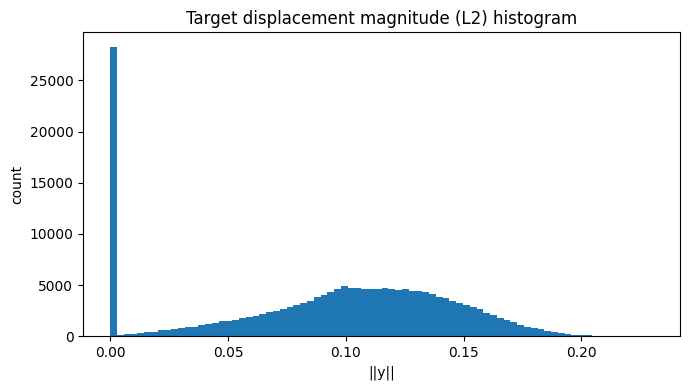

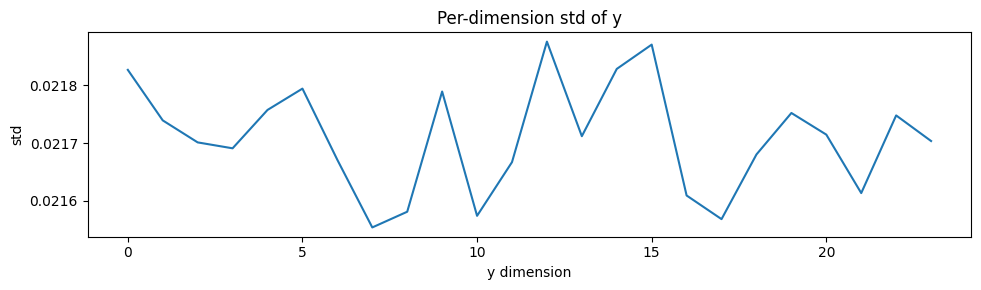

In [3]:
# --------
# Sanity tests + dataset visuals
# --------

y_class = data["y_class"].astype(np.int64)
y_class_onehot = data["y_class_onehot"].astype(np.float32)
class_names = [str(x) for x in data["class_names"].tolist()]

assert X.ndim == 2 and y.ndim == 2
assert X.shape[0] == y.shape[0]
assert y_class.shape[0] == X.shape[0]
assert y_class_onehot.shape == (X.shape[0], len(class_names))
assert np.all((y_class_onehot.sum(axis=1) == 1.0) | (y_class_onehot.sum(axis=1) == 0.0))

print("Basic checks:")
print("  any NaNs in X?", bool(np.isnan(X).any()))
print("  any NaNs in y?", bool(np.isnan(y).any()))
print("  class_names:", len(class_names))

y_norm = np.linalg.norm(y, axis=1)
print("\nTarget magnitude stats (L2 over 24 dims):")
print("  mean:", float(np.mean(y_norm)))
print("  p50:", float(np.percentile(y_norm, 50)))
print("  p90:", float(np.percentile(y_norm, 90)))
print("  frac(|y|<1e-6):", float(np.mean(y_norm < 1e-6)))
print("  frac(|y|<1e-3):", float(np.mean(y_norm < 1e-3)))

plt.figure(figsize=(7, 4))
plt.hist(y_norm, bins=80)
plt.title("Target displacement magnitude (L2) histogram")
plt.xlabel("||y||")
plt.ylabel("count")
plt.tight_layout()
plt.show()

y_std = np.std(y, axis=0)
plt.figure(figsize=(10, 3))
plt.plot(y_std)
plt.title("Per-dimension std of y")
plt.xlabel("y dimension")
plt.ylabel("std")
plt.tight_layout()
plt.show()


In [4]:
pose_dim = int(metadata["X_pose_flat_dim"])
class_dim = int(metadata["X_class_dim"])
y_dim = int(metadata["y_final_disp_flat_dim"])

assert X.shape[1] == pose_dim + class_dim
assert y.shape[1] == y_dim

# NOTE: rows are per-frame. A truly fair split is by *video*, but the row->video
# mapping is not stored in the .npz. We at least stratify by workout class.

def stratified_split_indices(y_class_idx: np.ndarray, *, seed: int = 42, train_frac=0.8, val_frac=0.1):
    rng = np.random.default_rng(seed)
    train, val, test = [], [], []
    for c in np.unique(y_class_idx):
        c_idx = np.where(y_class_idx == c)[0]
        rng.shuffle(c_idx)
        n = len(c_idx)
        n_train = int(train_frac * n)
        n_val = int(val_frac * n)
        train.append(c_idx[:n_train])
        val.append(c_idx[n_train : n_train + n_val])
        test.append(c_idx[n_train + n_val :])
    return np.concatenate(train), np.concatenate(val), np.concatenate(test)

train_idx, val_idx, test_idx = stratified_split_indices(y_class, seed=42)
rng = np.random.default_rng(42)
rng.shuffle(train_idx)
rng.shuffle(val_idx)
rng.shuffle(test_idx)

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print("Split sizes:")
print(f"  train: {X_train.shape}")
print(f"  val:   {X_val.shape}")
print(f"  test:  {X_test.shape}")

for name, idxs in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    counts = np.bincount(y_class[idxs], minlength=len(class_names))
    top = np.argsort(-counts)[:5]
    print(f"\n{name} top-5 classes:")
    for k in top:
        if counts[k] > 0:
            print(f"  {class_names[k]:<22} {int(counts[k])}")


Split sizes:
  train: (150927, 29)
  val:   (18864, 29)
  test:  (18870, 29)

train top-5 classes:
  pull_ups               47734
  bicep_curls            33616
  lateral_raises         23939
  push_ups               23842
  deadlift               21796

val top-5 classes:
  pull_ups               5966
  bicep_curls            4202
  lateral_raises         2992
  push_ups               2980
  deadlift               2724

test top-5 classes:
  pull_ups               5968
  bicep_curls            4203
  lateral_raises         2993
  push_ups               2981
  deadlift               2725


In [5]:
# --------
# Residual DNN: pre-norm blocks (LN -> two same-width dense layers -> + skip) + stem/head.
# Default: hidden_dim=256, 4 blocks, head_dim=128 (simpler than a wide 10-block ResMLP-FFN).
# --------

norm = layers.Normalization(axis=-1)
norm.adapt(X_train)

# Loss / metrics: only joints with non-zero *ground-truth* displacement (per sample).
_N_J = int(metadata["n_landmarks"])
_N_C = int(metadata["n_coords"])
_HUBER_DELTA = 0.05
_DISP_EPS = 1e-6


def masked_displaced_joint_huber(y_true, y_pred):
    yt = tf.reshape(y_true, (-1, _N_J, _N_C))
    yp = tf.reshape(y_pred, (-1, _N_J, _N_C))
    err = yt - yp
    joint_norm_true = tf.linalg.norm(yt, axis=-1)
    mask = tf.cast(joint_norm_true > _DISP_EPS, tf.float32)
    mask_w = tf.expand_dims(mask, -1)
    abs_err = tf.abs(err)
    quad = 0.5 * tf.square(err)
    lin = _HUBER_DELTA * (abs_err - 0.5 * _HUBER_DELTA)
    huber = tf.where(abs_err <= _HUBER_DELTA, quad, lin)
    masked = huber * mask_w
    denom = tf.reduce_sum(mask_w) + 1e-8
    return tf.reduce_sum(masked) / denom


def masked_displaced_joint_mae(y_true, y_pred):
    yt = tf.reshape(y_true, (-1, _N_J, _N_C))
    yp = tf.reshape(y_pred, (-1, _N_J, _N_C))
    joint_norm_true = tf.linalg.norm(yt, axis=-1)
    mask = tf.cast(joint_norm_true > _DISP_EPS, tf.float32)
    mask_w = tf.expand_dims(mask, -1)
    ae = tf.abs(yt - yp) * mask_w
    denom = tf.reduce_sum(mask_w) + 1e-8
    return tf.reduce_sum(ae) / denom


def residual_block(
    x,
    width: int,
    dropout: float = 0.1,
    name: str | None = None,
):
    # Pre-norm residual: LN, two width-wide layers, + skip
    shortcut = x
    h = layers.LayerNormalization(epsilon=1e-5, name=None if name is None else f"{name}_ln")(x)
    h = layers.Dense(
        width,
        activation="swish",
        name=None if name is None else f"{name}_fc1",
    )(h)
    h = layers.Dropout(dropout, name=None if name is None else f"{name}_drop")(h)
    h = layers.Dense(width, name=None if name is None else f"{name}_fc2")(h)
    return layers.Add(name=None if name is None else f"{name}_add")([shortcut, h])


def build_dnn(
    input_dim: int,
    output_dim: int,
    *,
    hidden_dim: int = 256,
    n_blocks: int = 4,
    head_dim: int = 128,
    dropout: float = 0.1,
) -> keras.Model:
    inp = keras.Input(shape=(input_dim,), name="X")
    x = norm(inp)
    x = layers.Dense(hidden_dim, activation="swish", name="stem")(x)
    for i in range(n_blocks):
        x = residual_block(
            x,
            hidden_dim,
            dropout=dropout,
            name=f"block_{i}",
        )
    x = layers.LayerNormalization(epsilon=1e-5, name="post_ln")(x)
    x = layers.Dense(head_dim, activation="swish", name="head_fc")(x)
    out = layers.Dense(output_dim, name="y_pred")(x)
    return keras.Model(inp, out, name="residual_dnn")


model = build_dnn(input_dim=X.shape[1], output_dim=y.shape[1])
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=masked_displaced_joint_huber,
    metrics=[masked_displaced_joint_mae],
)
model.summary()


Model: "residual_dnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ X (InputLayer)      │ (None, 29)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 29)        │         59 │ X[0][0]           │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem (Dense)        │ (None, 256)       │      7,680 │ normalization[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_0_ln          │ (None, 256)       │        512 │ stem[0][0]        │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_0_fc1 (Dense) │ (None, 256)       │     65,792 │ block_0_ln[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_0_drop        │ (None, 256)       │          0 │ block_0_fc1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_0_fc2 (Dense) │ (None, 256)       │     65,792 │ block_0_drop[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_0_add (Add)   │ (None, 256)       │          0 │ stem[0][0],       │
│                     │                   │            │ block_0_fc2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_ln          │ (None, 256)       │        512 │ block_0_add[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_fc1 (Dense) │ (None, 256)       │     65,792 │ block_1_ln[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_drop        │ (None, 256)       │          0 │ block_1_fc1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_fc2 (Dense) │ (None, 256)       │     65,792 │ block_1_drop[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_add (Add)   │ (None, 256)       │          0 │ block_0_add[0][0… │
│                     │                   │            │ block_1_fc2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_ln          │ (None, 256)       │        512 │ block_1_add[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_fc1 (Dense) │ (None, 256)       │     65,792 │ block_2_ln[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_drop        │ (None, 256)       │          0 │ block_2_fc1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_fc2 (Dense) │ (None, 256)       │     65,792 │ block_2_drop[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_add (Add)   │ (None, 256)       │          0 │ block_1_add[0][0… │
│                     │                   │            │ block_2_fc2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_3_ln          │ (None, 256)       │        512 │ block_2_add[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 572,627 (2.18 MB)

 Trainable params: 572,568 (2.18 MB)

 Non-trainable params: 59 (240.00 B)

In [6]:
# --------
# Baselines (to calibrate what 'good' means)
# --------

def mae_global(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))


def mae_masked_displaced(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    yt = y_true.reshape((-1, _N_J, _N_C))
    yp = y_pred.reshape((-1, _N_J, _N_C))
    mask = (np.linalg.norm(yt, axis=-1) > _DISP_EPS)[..., None]
    ae = np.abs(yt - yp) * mask
    return float(ae.sum() / max(mask.sum(), 1.0))


zero_pred = np.zeros_like(y_test)
mean_pred = np.repeat(np.mean(y_train, axis=0, keepdims=True), repeats=y_test.shape[0], axis=0)

print("Baseline: predict all zeros")
print(f"  unmasked MAE         : {mae_global(y_test, zero_pred):.6f}  (dominated by zero targets, not informative)")
print(f"  masked MAE (disp jt) : {mae_masked_displaced(y_test, zero_pred):.6f}  <- track THIS")

print("\nBaseline: predict train mean")
print(f"  unmasked MAE         : {mae_global(y_test, mean_pred):.6f}")
print(f"  masked MAE (disp jt) : {mae_masked_displaced(y_test, mean_pred):.6f}")


Baseline: predict all zeros
  unmasked MAE         : 0.007052  (dominated by zero targets, not informative)
  masked MAE (disp jt) : 0.099754  <- track THIS

Baseline: predict train mean
  unmasked MAE         : 0.007099
  masked MAE (disp jt) : 0.099753


In [7]:
cbs = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6),
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=256,
    callbacks=cbs,
    verbose=1,
)


Epoch 1/30
590/590 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0025 - masked_displaced_joint_mae: 0.0868 - val_loss: 8.6825e-04 - val_masked_displaced_joint_mae: 0.0460 - learning_rate: 0.0010
Epoch 2/30
590/590 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7.6182e-04 - masked_displaced_joint_mae: 0.0430 - val_loss: 6.2092e-04 - val_masked_displaced_joint_mae: 0.0381 - learning_rate: 0.0010
Epoch 3/30
590/590 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 6.4002e-04 - masked_displaced_joint_mae: 0.0388 - val_loss: 5.9437e-04 - val_masked_displaced_joint_mae: 0.0373 - learning_rate: 0.0010
Epoch 4/30
590/590 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5.8958e-04 - masked_displaced_joint_mae: 0.0371 - val_loss: 5.4536e-04 - val_masked_displaced_joint_mae: 0.0354 - learning_rate: 0.0010
Epoch 5/30
590/590 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5.5798e-04 - masked_displaced_joint_mae: 0.0359 - val_loss: 5.3421e-04 - val_masked_displaced_joint_mae: 0.0350 - learning_rate: 0.0010
Epoch 6/30
590/590 ━━━━━

In [8]:
def r2_score_np(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true, axis=0, keepdims=True)) ** 2))
    return 1.0 - ss_res / (ss_tot + 1e-12)

y_pred = model.predict(X_test, batch_size=1024)

unmasked_mae = mae_global(y_test, y_pred)
masked_mae = mae_masked_displaced(y_test, y_pred)
r2 = r2_score_np(y_test, y_pred)

print(f"Test unmasked MAE          : {unmasked_mae:.6f}")
print(f"Test masked MAE (disp jt)  : {masked_mae:.6f}  (baseline predict-zero ≈ {mae_masked_displaced(y_test, zero_pred):.6f})")
print(f"Test R2 (global)           : {r2:.6f}")


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Test unmasked MAE          : 0.012909
Test masked MAE (disp jt)  : 0.024136  (baseline predict-zero ≈ 0.099754)
Test R2 (global)           : 0.292633


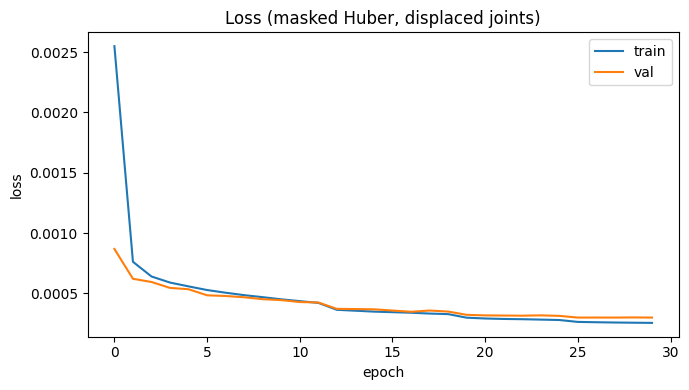

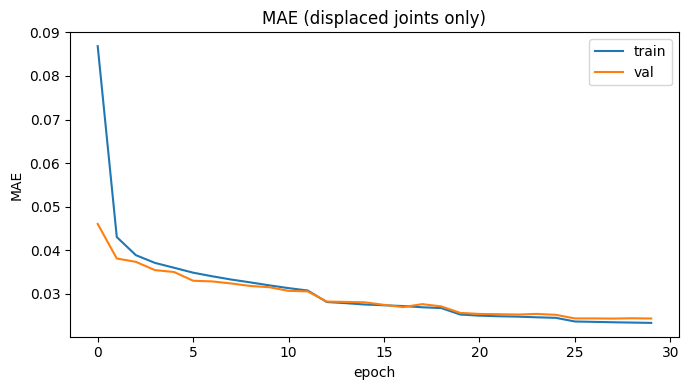

In [9]:
# --------
# Training curves
# --------

plt.figure(figsize=(7, 4))
plt.plot(history.history.get("loss", []), label="train")
plt.plot(history.history.get("val_loss", []), label="val")
plt.title("Loss (masked Huber, displaced joints)")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
_mae_key = "masked_displaced_joint_mae" if "masked_displaced_joint_mae" in history.history else "mae"
plt.plot(history.history.get(_mae_key, []), label="train")
plt.plot(history.history.get(f"val_{_mae_key}", []), label="val")
plt.title("MAE (displaced joints only)")
plt.xlabel("epoch")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()


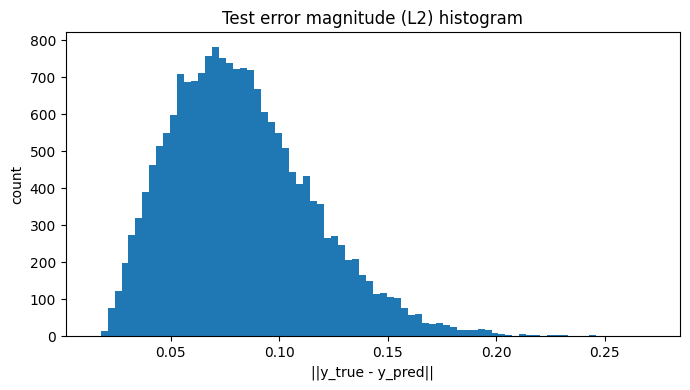

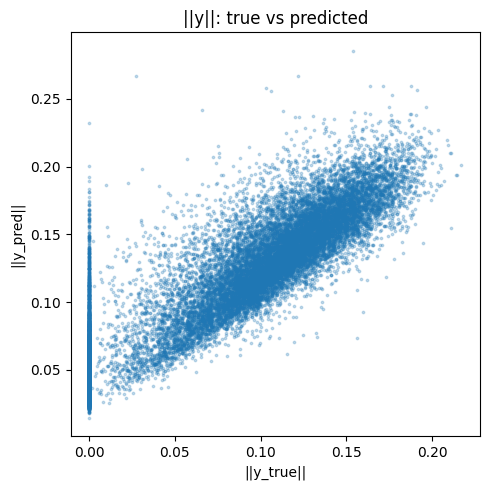

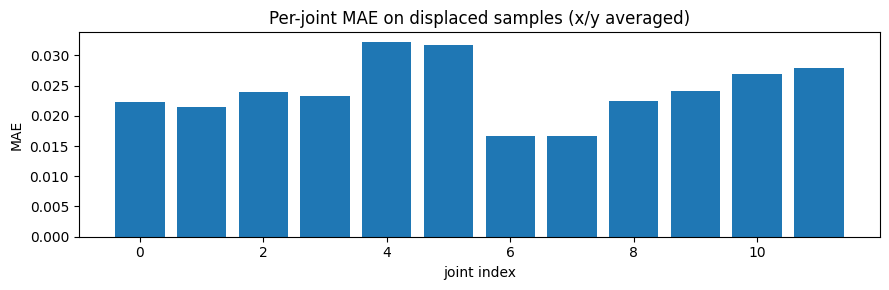

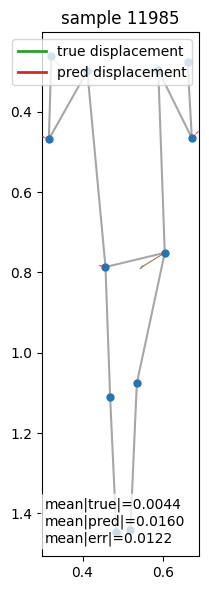

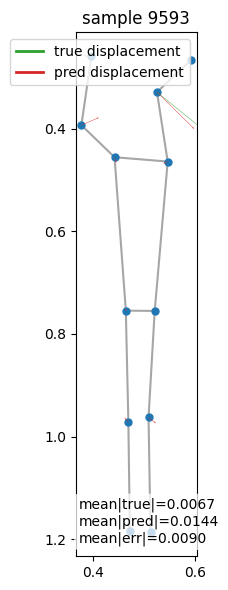

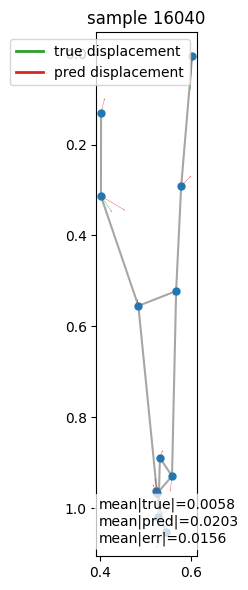

In [10]:
# --------
# Prediction visualizations + qualitative skeleton plots
# --------

n_landmarks = int(metadata["n_landmarks"])
n_coords = int(metadata["n_coords"])
pose_dim = int(metadata["X_pose_flat_dim"])

# Landmark order (from Data/video_pose_extractor_displacement_per_frame.py):
# 0 left_shoulder, 1 right_shoulder, 2 left_elbow, 3 right_elbow,
# 4 left_wrist, 5 right_wrist, 6 left_hip, 7 right_hip,
# 8 left_knee, 9 right_knee, 10 left_ankle, 11 right_ankle
edges = [
    (0, 1),
    (6, 7),
    (0, 2), (2, 4),
    (1, 3), (3, 5),
    (0, 6), (1, 7),
    (6, 8), (8, 10),
    (7, 9), (9, 11),
]


def plot_skeleton_with_arrows(pose_xy, disp_true_xy, disp_pred_xy, title=""):
    from matplotlib.lines import Line2D

    pose_xy = np.asarray(pose_xy)
    dt = np.asarray(disp_true_xy)
    dp = np.asarray(disp_pred_xy)

    fig, ax = plt.subplots(figsize=(6, 6))

    for i, j in edges:
        ax.plot([pose_xy[i, 0], pose_xy[j, 0]], [pose_xy[i, 1], pose_xy[j, 1]], "k-", alpha=0.35, zorder=1)
    ax.scatter(pose_xy[:, 0], pose_xy[:, 1], s=25, zorder=2)

    ax.quiver(
        pose_xy[:, 0], pose_xy[:, 1], dt[:, 0], dt[:, 1],
        angles="xy", scale_units="xy", scale=1.0, color="tab:green", alpha=0.85, width=0.004, zorder=3,
    )
    ax.quiver(
        pose_xy[:, 0], pose_xy[:, 1], dp[:, 0], dp[:, 1],
        angles="xy", scale_units="xy", scale=1.0, color="tab:red", alpha=0.85, width=0.004, zorder=4,
    )

    proxies = [
        Line2D([0], [0], color="tab:green", lw=2, label="true displacement"),
        Line2D([0], [0], color="tab:red", lw=2, label="pred displacement"),
    ]
    ax.legend(handles=proxies, loc="upper right")

    true_ma = float(np.mean(np.abs(dt)))
    pred_ma = float(np.mean(np.abs(dp)))
    err_ma = float(np.mean(np.abs(dt - dp)))
    ax.text(
        0.02, 0.02,
        f"mean|true|={true_ma:.4f}\nmean|pred|={pred_ma:.4f}\nmean|err|={err_ma:.4f}",
        transform=ax.transAxes, fontsize=10, va="bottom", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none"), zorder=10,
    )

    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    fig.tight_layout()
    plt.show()


# Global error histogram
err = (y_test - y_pred)
err_norm = np.linalg.norm(err, axis=1)
plt.figure(figsize=(7, 4))
plt.hist(err_norm, bins=80)
plt.title("Test error magnitude (L2) histogram")
plt.xlabel("||y_true - y_pred||")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# Scatter: true vs pred norms
plt.figure(figsize=(5, 5))
plt.scatter(np.linalg.norm(y_test, axis=1), np.linalg.norm(y_pred, axis=1), s=3, alpha=0.25)
plt.title("||y||: true vs predicted")
plt.xlabel("||y_true||")
plt.ylabel("||y_pred||")
plt.tight_layout()
plt.show()

# Per-joint MAE (over x/y, displaced joints only for fairness)
y_test_n = y_test.reshape((-1, n_landmarks, n_coords))
y_pred_n = y_pred.reshape((-1, n_landmarks, n_coords))
mask_n = (np.linalg.norm(y_test_n, axis=-1) > _DISP_EPS)[..., None]
ae_n = np.abs(y_test_n - y_pred_n) * mask_n
per_joint_mae_disp = ae_n.sum(axis=(0, 2)) / np.maximum(mask_n.sum(axis=(0, 2)), 1.0)
plt.figure(figsize=(9, 3))
plt.bar(np.arange(n_landmarks), per_joint_mae_disp)
plt.title("Per-joint MAE on displaced samples (x/y averaged)")
plt.xlabel("joint index")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

# Qualitative samples (prefer ones that actually have displacement)
rows_with_disp = np.where(np.linalg.norm(y_test, axis=1) > _DISP_EPS)[0]
if rows_with_disp.size == 0:
    rows_with_disp = np.arange(X_test.shape[0])
rng = np.random.default_rng(0)
sel = rng.choice(rows_with_disp, size=min(3, len(rows_with_disp)), replace=False)
for k in sel:
    pose_xy = X_test[k, :pose_dim].reshape((n_landmarks, n_coords))[:, :2]
    y_true_xy = y_test[k].reshape((n_landmarks, n_coords))[:, :2]
    y_pred_xy = y_pred[k].reshape((n_landmarks, n_coords))[:, :2]
    plot_skeleton_with_arrows(pose_xy, y_true_xy, y_pred_xy, title=f"sample {int(k)}")


In [11]:
out_dir = Path("./saved_models")
out_dir.mkdir(parents=True, exist_ok=True)
save_path = out_dir / "dnn_single_frame_displacement.keras"
model.save(save_path)
print(f"Saved to: {save_path}")


Saved to: saved_models/dnn_single_frame_displacement.keras
